# Exploration d'un run

Ce notebook **n'exécute aucune simulation** : il lit les artefacts d'un run déjà
produit par le pipeline.

```bash
python main.py run --config experiments/full_grid.yaml
```

Toute la logique d'expérience vit dans `src/pipeline/` et se pilote en ligne de
commande. Ce notebook sert uniquement à explorer les résultats de façon
interactive — y ajouter du code de simulation ou de configuration recréerait la
duplication que le pipeline a supprimée.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import pandas as pd
from IPython.display import Image, display

from src.pipeline.store import RunStore
from src.pipeline import figures

## Choix du run

`RunStore.latest()` prend le plus récent ; passer un chemin à `RunStore.open()`
pour en cibler un autre.

In [2]:
for path in RunStore.list_runs('../results_grid'):
    print(path)

../results_grid/20260823T180259Z_seed42_full-grid


In [3]:
store = RunStore.latest('../results_grid')
params = store.read_params()
manifest = store.read_manifest()

print(store.root)
print(params.describe())
print(f"graine={params.seed} | commit={manifest['git_commit']} | "
      f"cas={manifest['nb_cases_done']}/{manifest['nb_cases_planned']}")

../results_grid/20260823T180259Z_seed42_full-grid
seed=42 | scénarios=['optimistic', 'balance', 'pessimistic'] | flottes=[50, 100, 150, 200, 250] | méthodes=['greedy', 'bramev'] | 1440 slots (5.0 j) | 40 stations / 4 sociétés | 30 runs
graine=42 | commit=68b16adcd760fe506374d09c57a8c60bfe263e27 | cas=30/30


## Tableau de synthèse

Une ligne par cas (scénario x flotte x méthode).

In [4]:
summary = pd.read_csv(store.summary_path)

colonnes = ['scenario', 'nb_cars', 'method', 'exact_satisfaction',
            'needs_satisfaction', 'mean_travel_distance_km',
            'mean_waiting_time_min', 'total_ms_mean',
            'nb_reservations', 'nb_pres', 'nb_no_show',
            'nb_early_canc', 'nb_late_canc', 'invariant_ok']
summary[colonnes]

,scenario,nb_cars,method,exact_satisfaction,needs_satisfaction,mean_travel_distance_km,mean_waiting_time_min,total_ms_mean,nb_reservations,nb_pres,nb_no_show,nb_early_canc,nb_late_canc,invariant_ok
0,optimistic,50,greedy,0.8789,0.9001,0.2859,0.024,59.600,442,325,45,0,72,True
1,optimistic,50,bramev,0.8714,0.8925,0.3315,0.000,480.649,434,320,44,0,70,True
2,optimistic,100,greedy,0.8911,0.9112,0.2916,1.692,71.952,854,639,80,6,129,True
3,optimistic,100,bramev,0.8909,0.9115,0.3391,0.024,1106.237,842,628,79,0,133,True
4,optimistic,150,greedy,0.8618,0.8827,0.2865,7.770,94.590,1302,981,123,19,179,True
5,optimistic,150,bramev,0.8904,0.9115,0.3300,0.684,3740.679,1262,953,118,3,187,True
6,optimistic,200,greedy,0.8121,0.8339,0.2830,17.886,239.849,1830,1367,174,36,252,True
7,optimistic,200,bramev,0.8864,0.9082,0.3477,1.164,21432.628,1689,1262,160,7,255,True
8,optimistic,250,greedy,0.7597,0.7809,0.2808,28.662,257.114,2349,1768,221,83,271,True
9,optimistic,250,bramev,0.8822,0.9074,0.3571,2.166,64648.241,2101,1584,200,8,301,True


## Comparaison des méthodes

Les deux méthodes d'un même couple (scénario, flotte) tournent sur le **même**
monde initial : l'écart mesuré est imputable à la méthode, pas au tirage.

In [5]:
pivot = summary.pivot_table(
    index=['scenario', 'nb_cars'],
    columns='method',
    values=['exact_satisfaction', 'mean_travel_distance_km', 'total_ms_mean'],
)
pivot

exact_satisfaction         mean_travel_distance_km  \
method                          bramev  greedy                  bramev   
scenario    nb_cars                                                      
balance     50                  0.7563  0.7596                  0.3976   
            100                 0.7801  0.7741                  0.3793   
            150                 0.7831  0.7458                  0.3749   
            200                 0.7750  0.6992                  0.3816   
            250                 0.7809  0.6427                  0.4015   
optimistic  50                  0.8714  0.8789                  0.3315   
            100                 0.8909  0.8911                  0.3391   
            150                 0.8904  0.8618                  0.3300   
            200                 0.8864  0.8121                  0.3477   
            250                 0.8822  0.7597                  0.3571   
pessimistic 50                  0.7012  0.7950                  0.4349   
            100                 0.6967  0.7383                  0.4371   
            150                 0.6718  0.6875                  0.4331   
            200                 0.6712  0.6483                  0.4410   
            250                 0.6712  0.6012                  0.4434   

                            total_ms_mean           
method               greedy        bramev   greedy  
scenario    nb_cars                                 
balance     50       0.3010       428.008   64.203  
            100      0.2846      1016.216   79.176  
            150      0.2864      3349.424  101.795  
            200      0.2841     18192.367  232.744  
            250      0.2838     55685.827  238.764  
optimistic  50       0.2859       480.649   59.600  
            100      0.2916      1106.237   71.952  
            150      0.2865      3740.679   94.590  
            200      0.2830     21432.628  239.849  
            250      0.2808     64648.241  257.114  
pessimistic 50       0.2860       439.747   71.142  
            100      0.2825       962.252   86.728  
            150      0.2842      3028.871  110.813  
            200      0.2828     16356.406  205.555  
            250      0.2808     50541.475  221.079

## Figures

Déjà écrites par le pipeline dans `figures/`. Pour les régénérer après avoir
modifié `src/pipeline/figures.py` :

```bash
python main.py report --latest
```

demand_funnel_balance.png


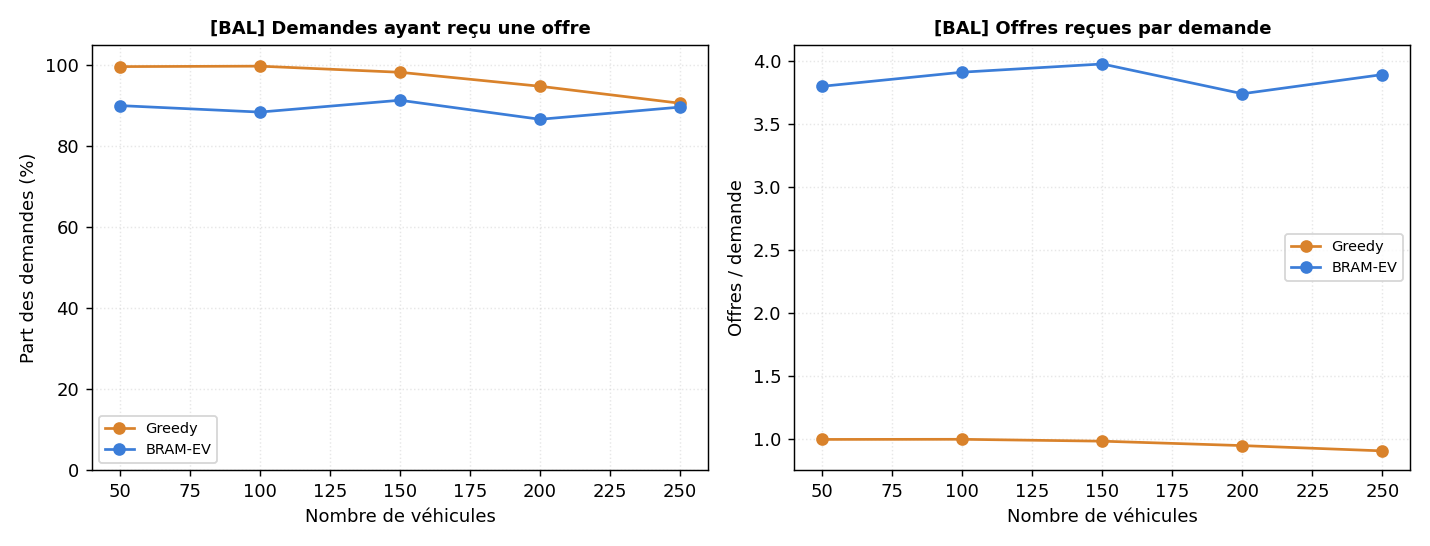

demand_funnel_optimistic.png


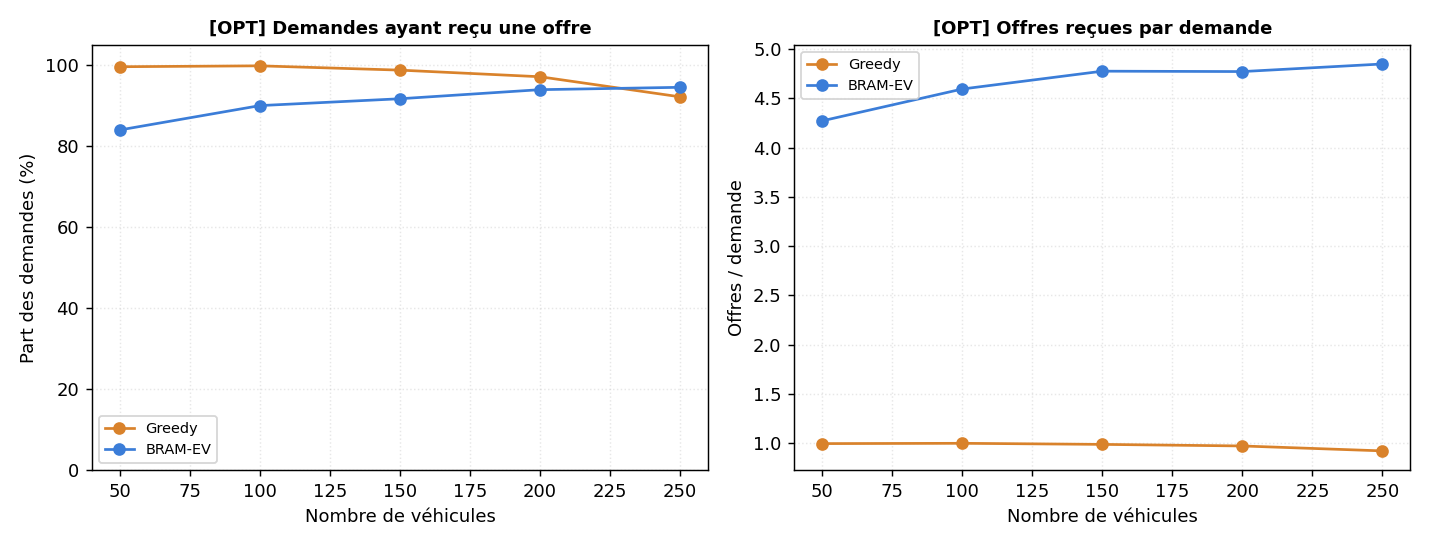

demand_funnel_pessimistic.png


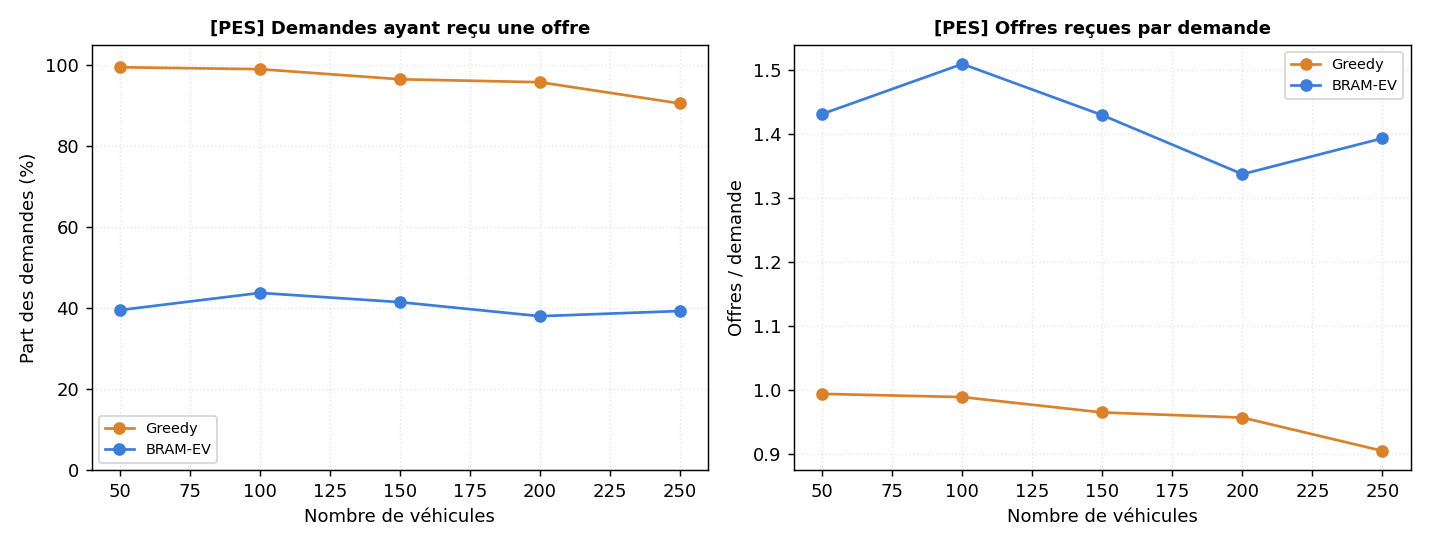

fleet_100cars.png


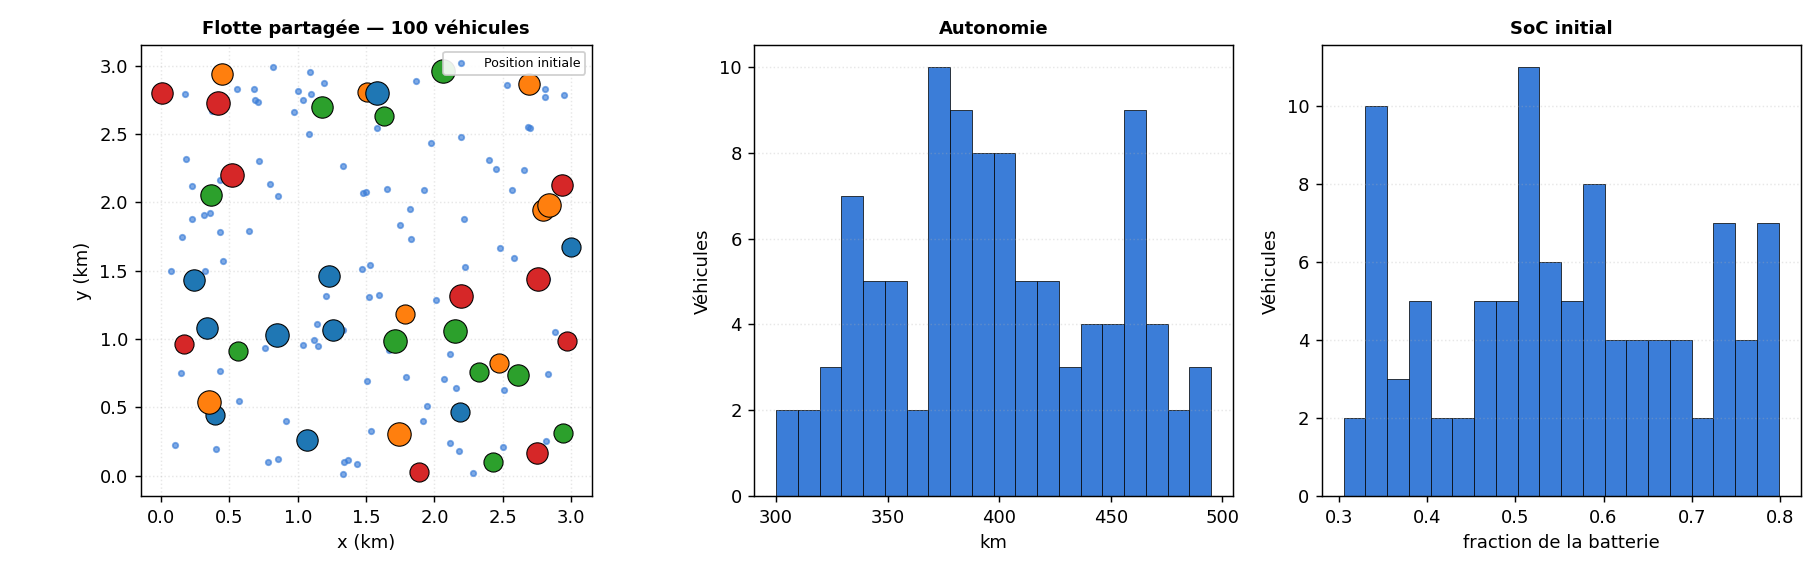

fleet_150cars.png


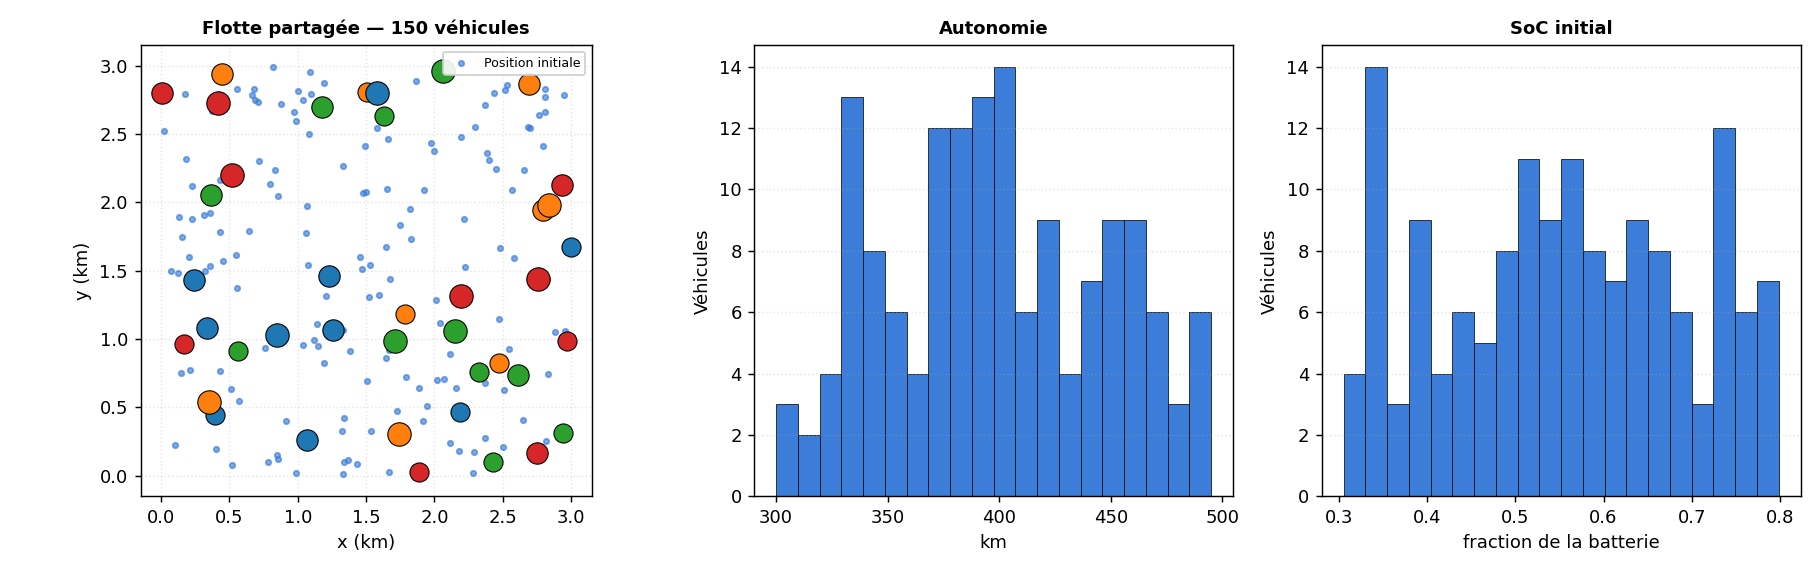

fleet_200cars.png


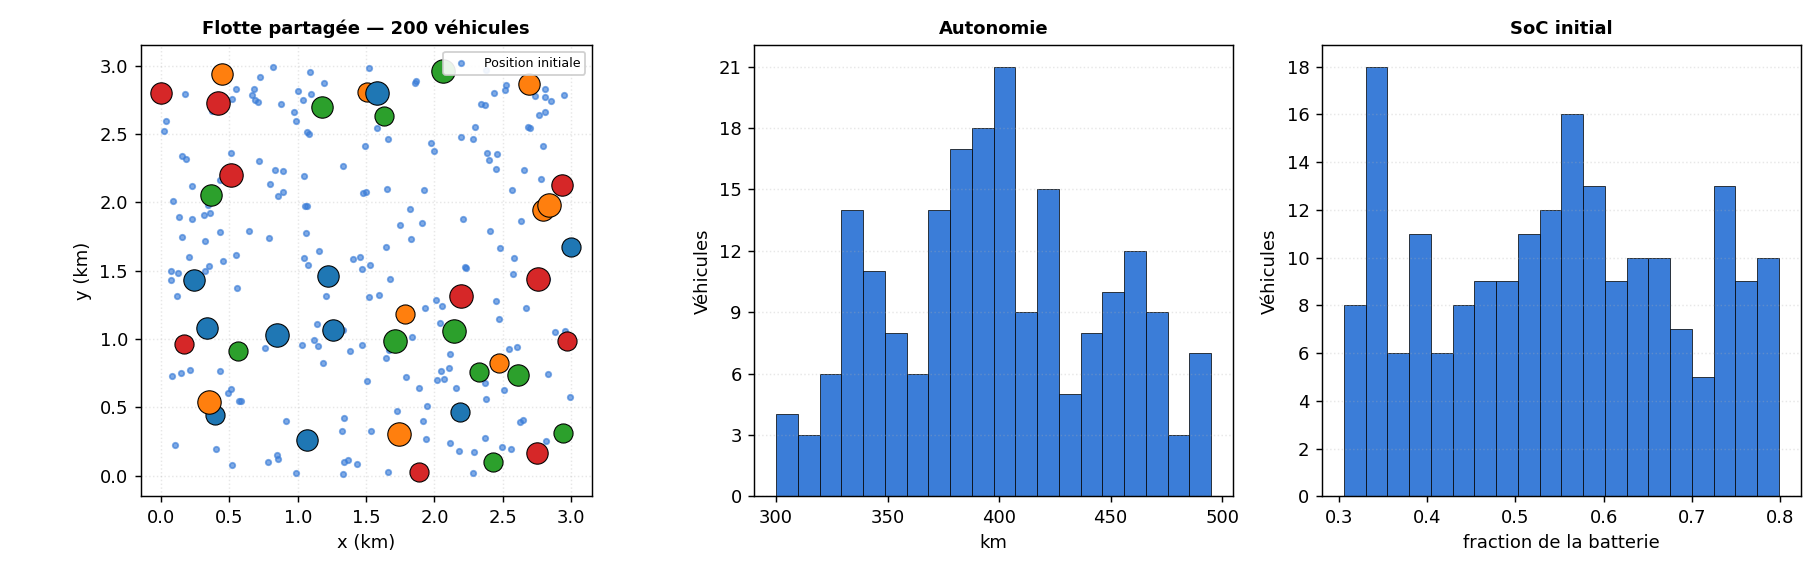

fleet_250cars.png


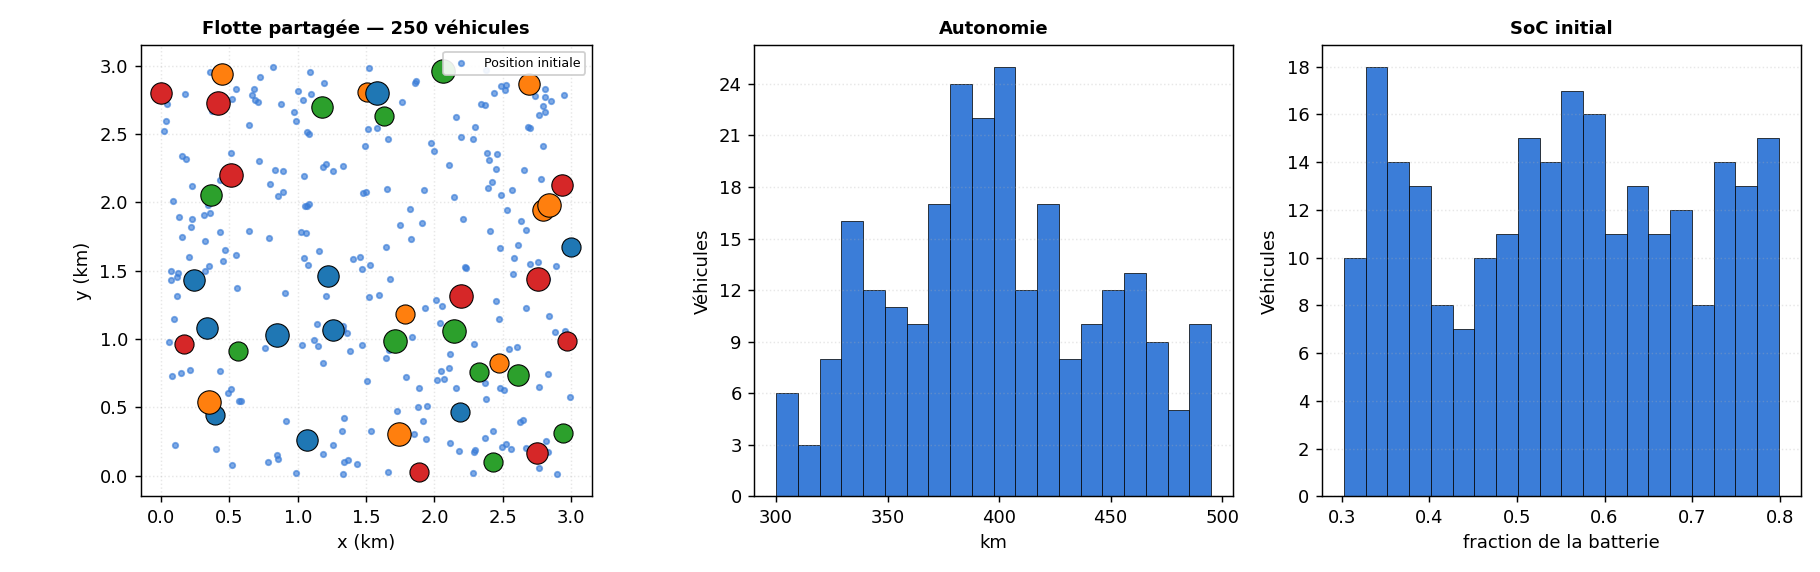

fleet_50cars.png


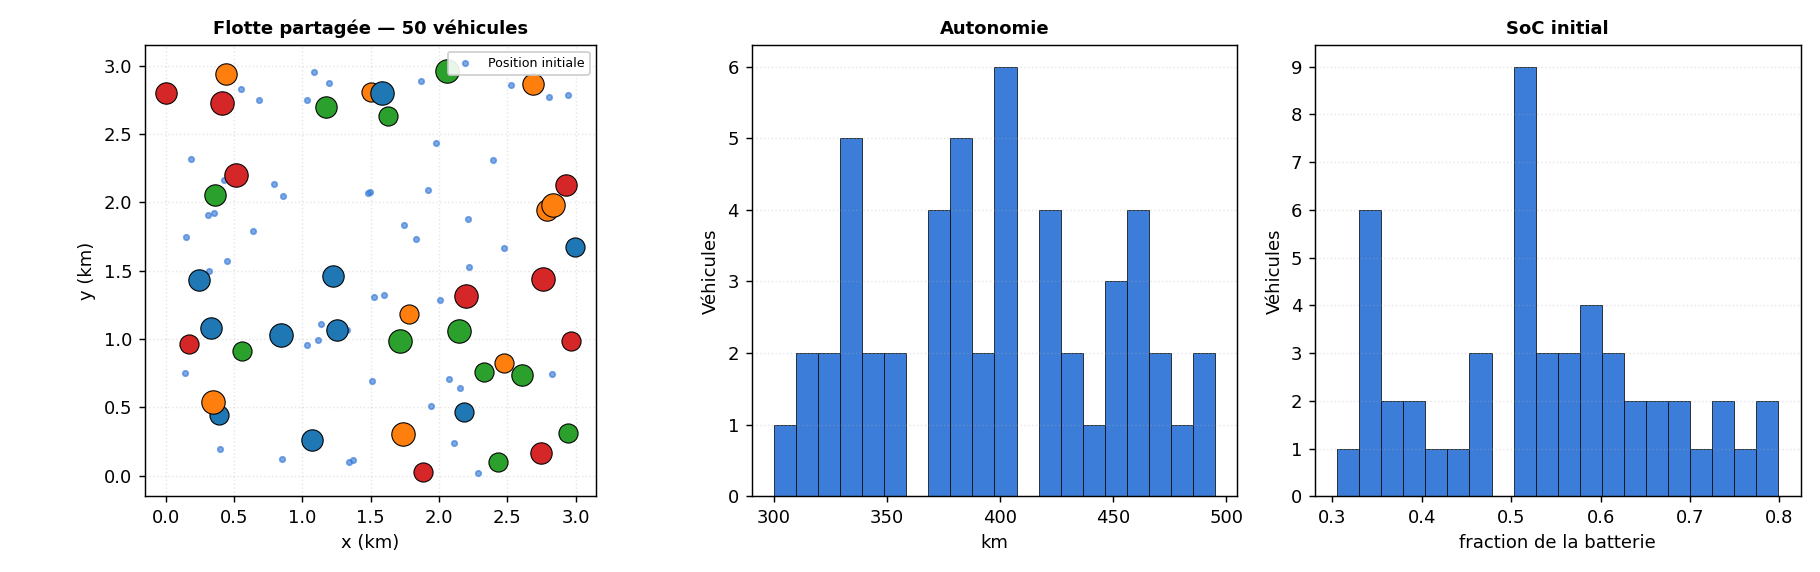

grid.png


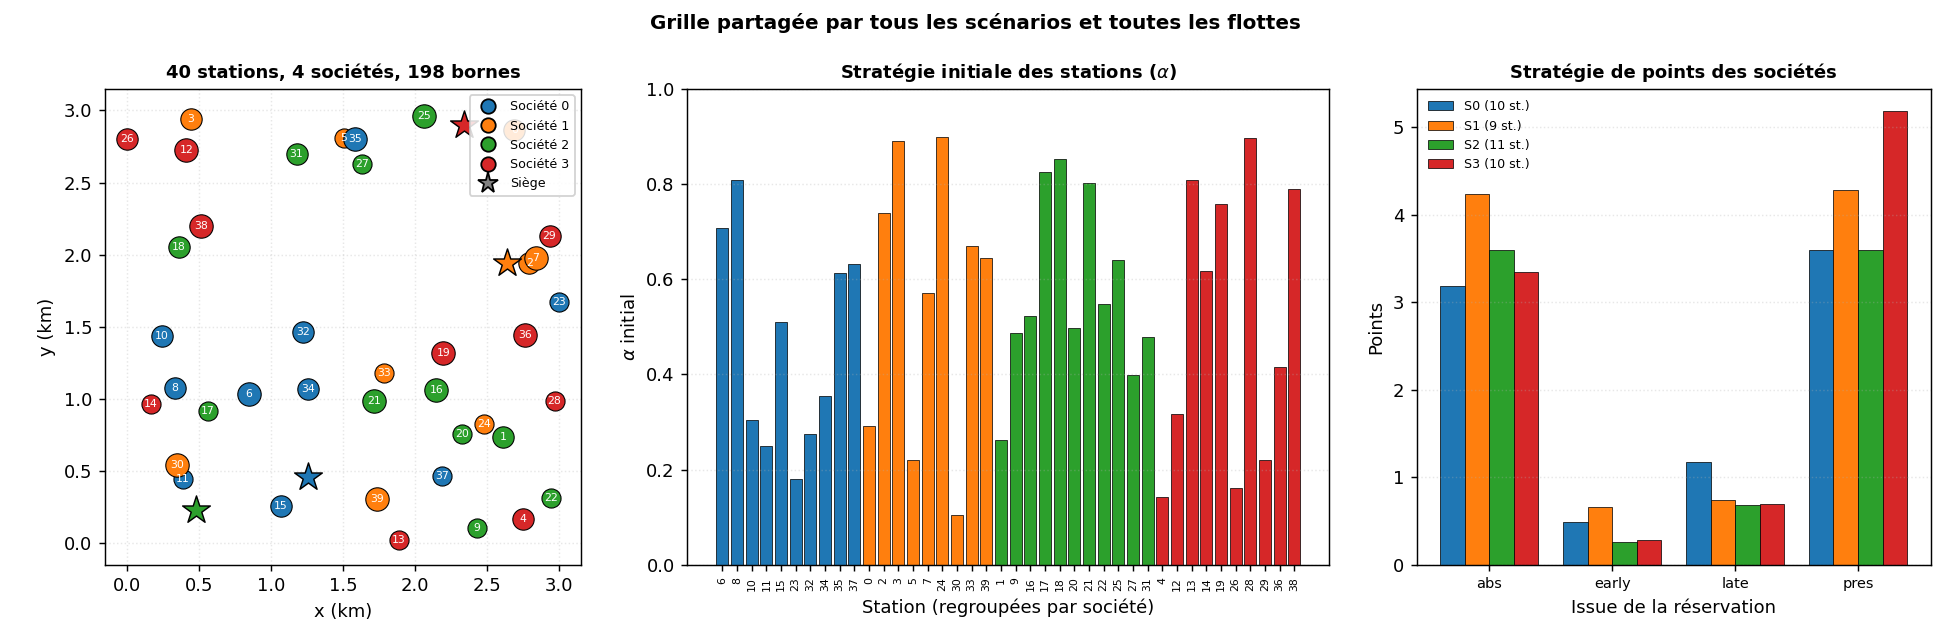

intent_vs_observed.png


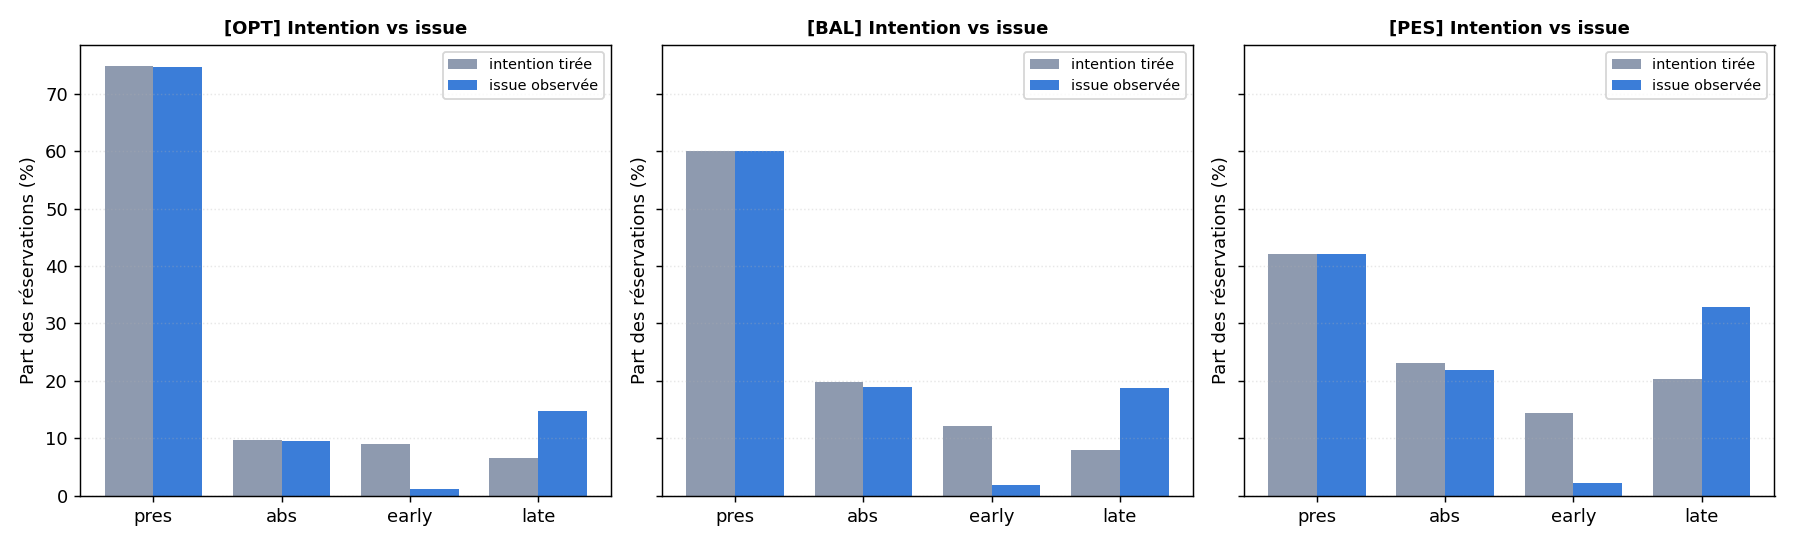

latency_balance.png


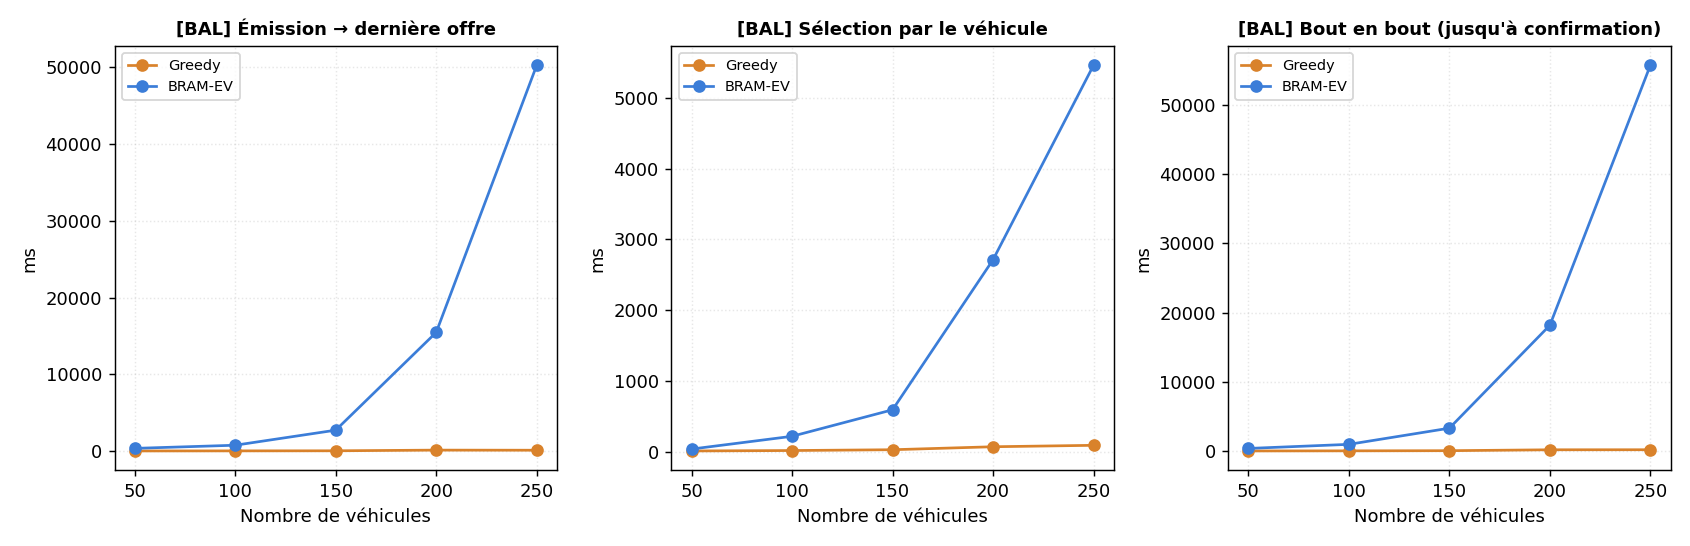

latency_optimistic.png


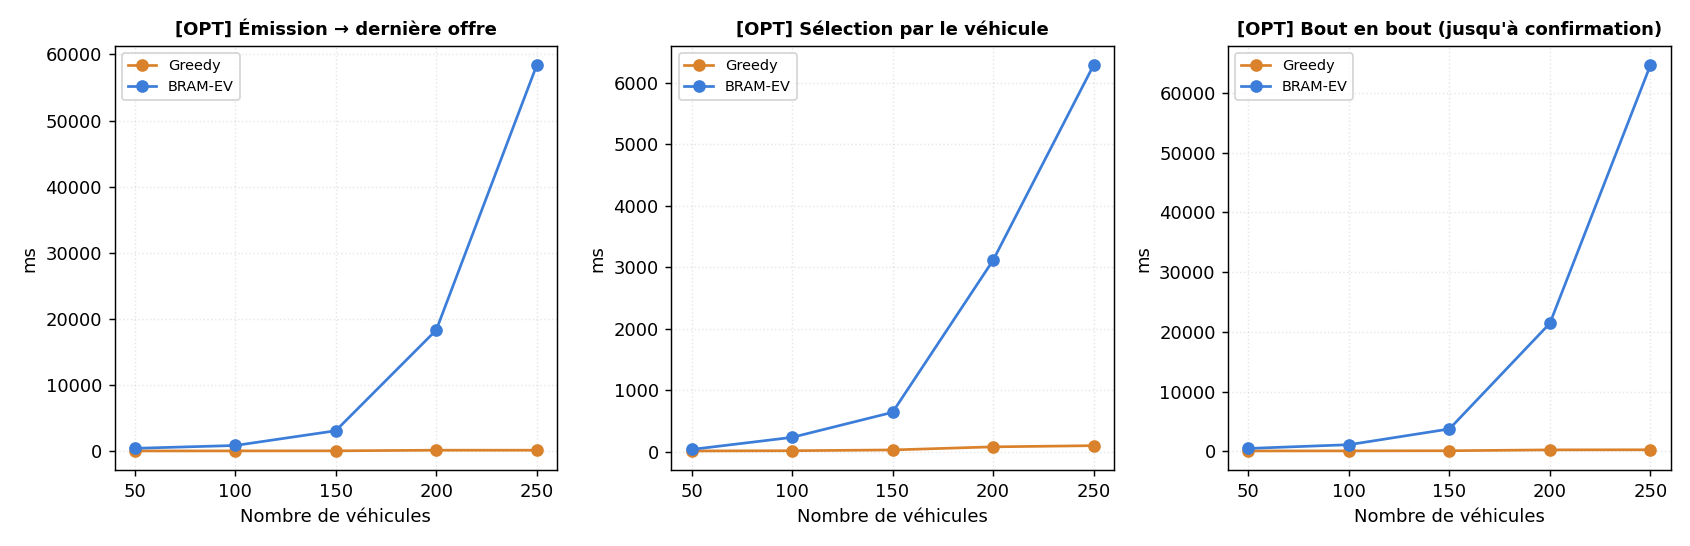

latency_pessimistic.png


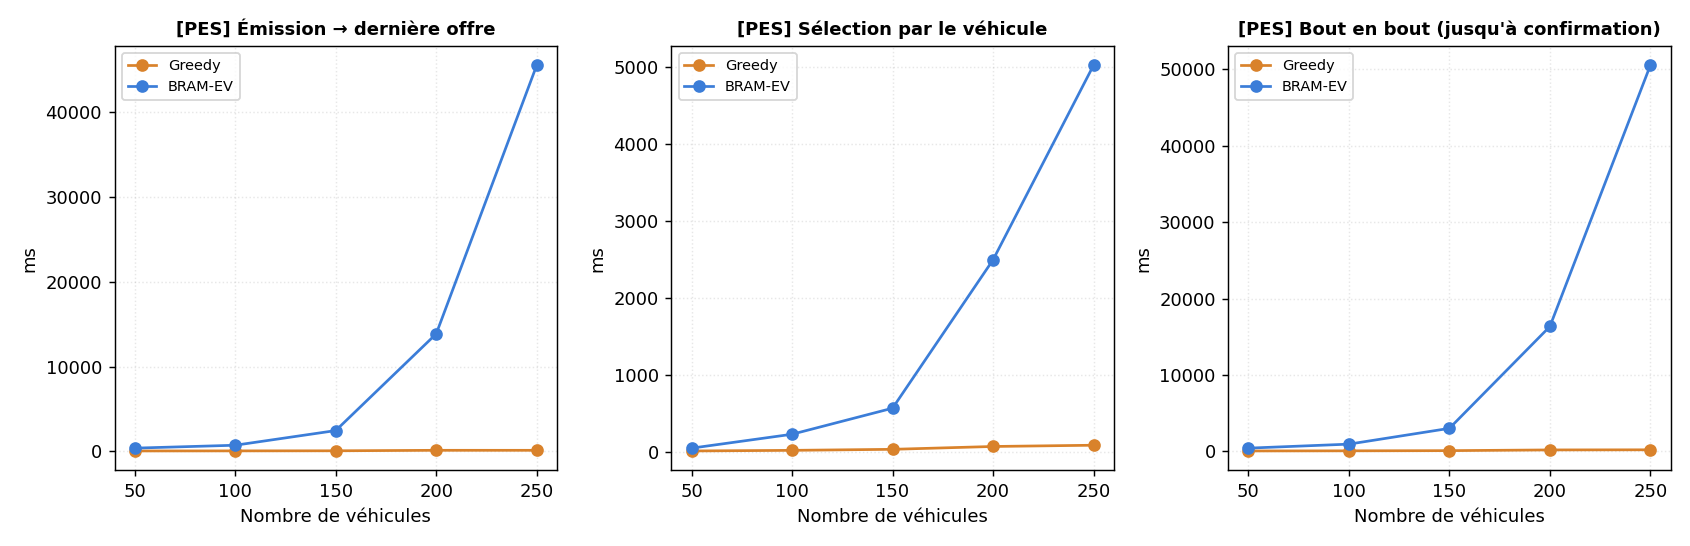

offer_protocol_balance.png


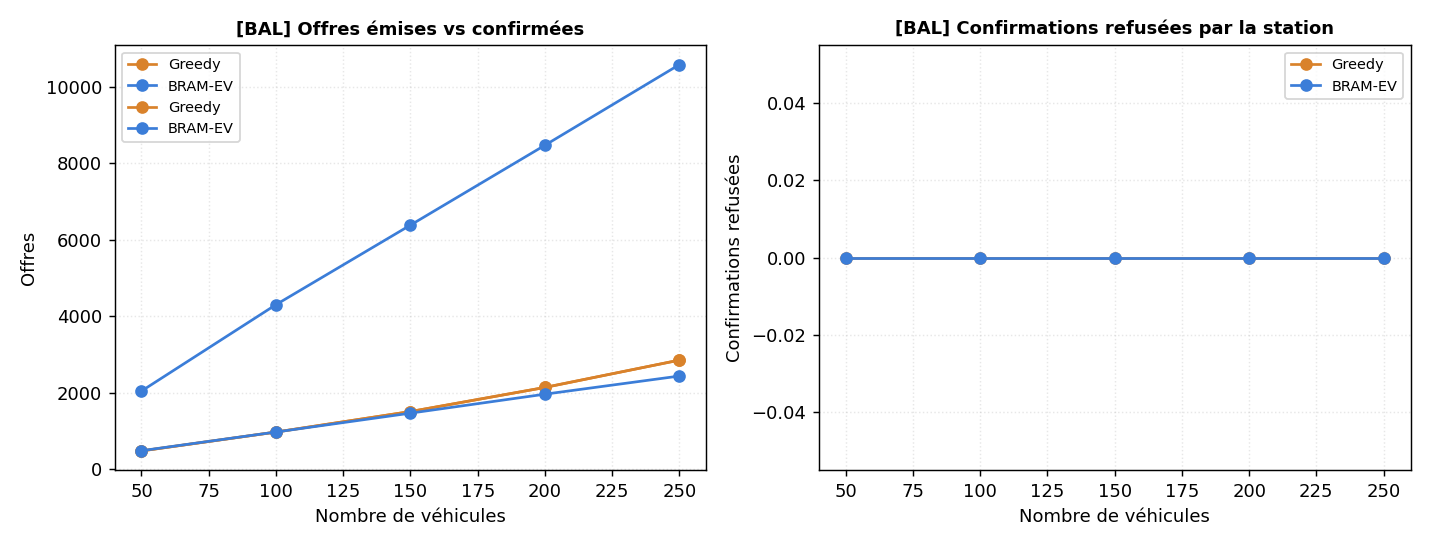

offer_protocol_optimistic.png


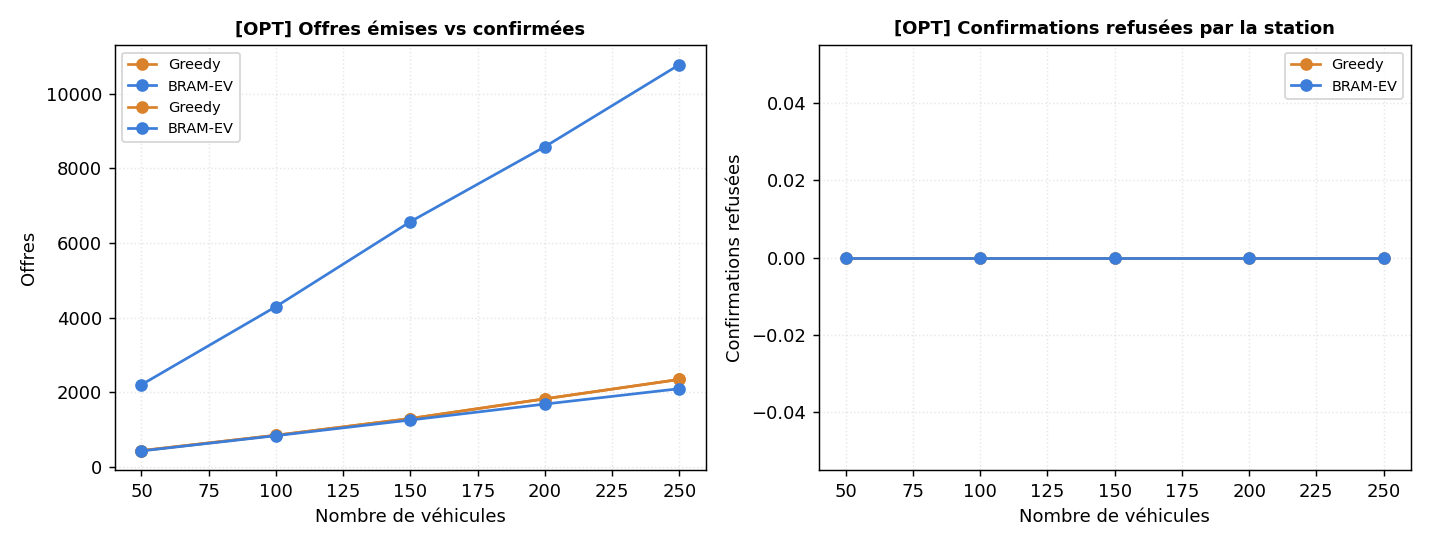

offer_protocol_pessimistic.png


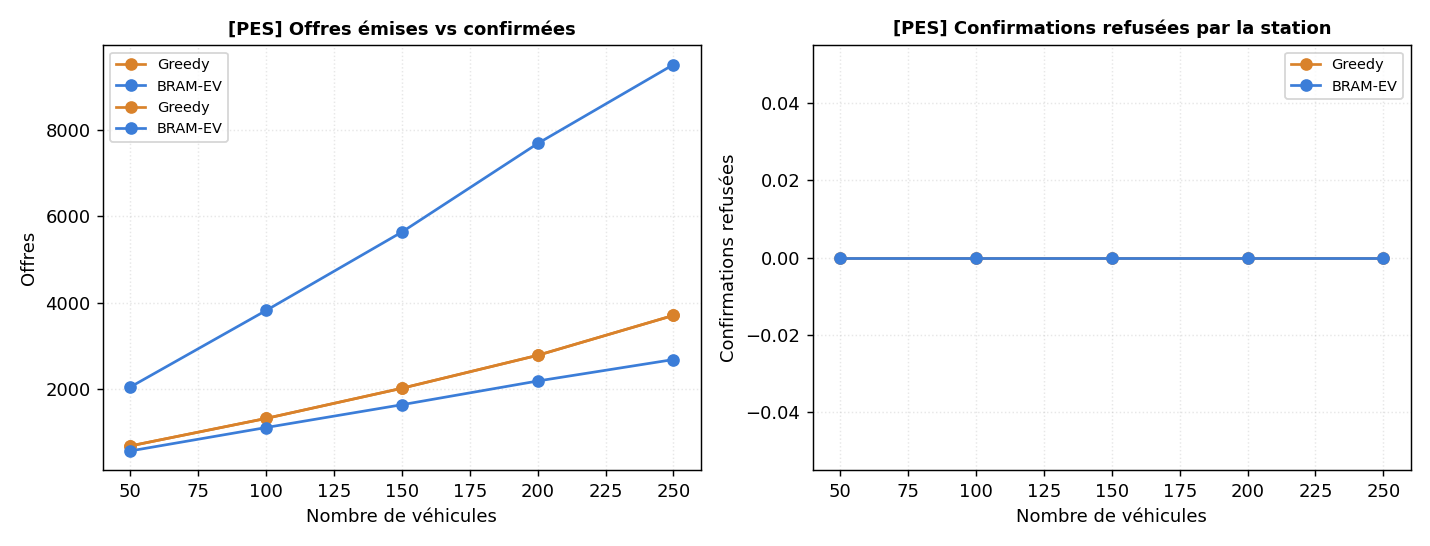

outcomes_balance.png


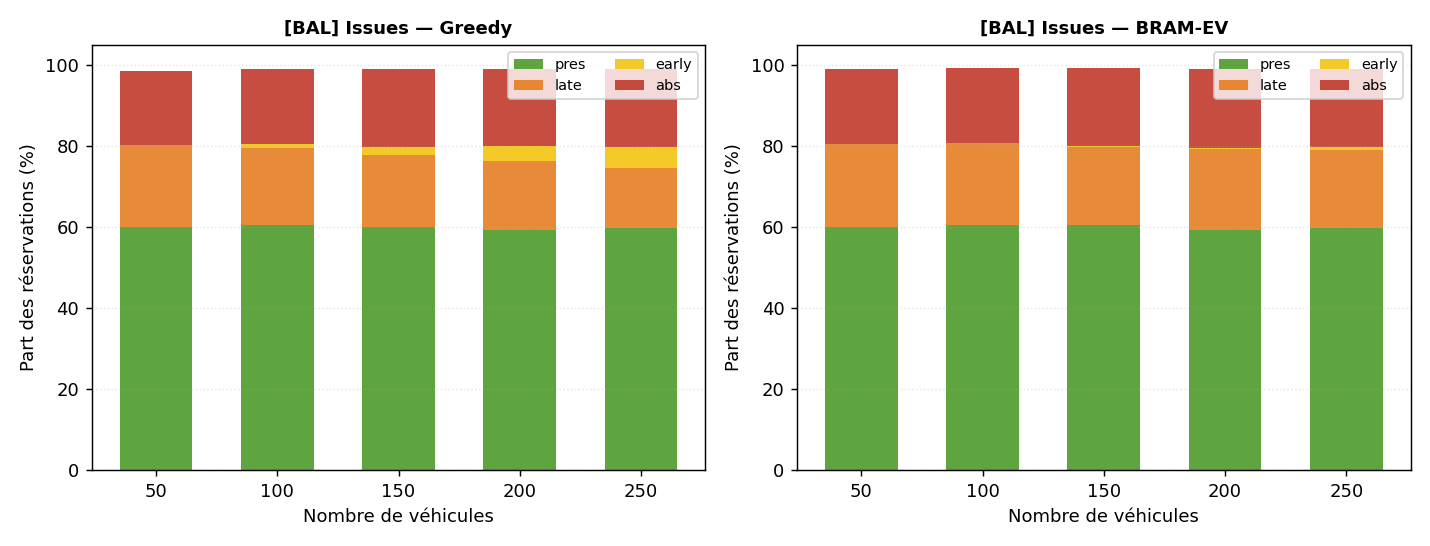

outcomes_optimistic.png


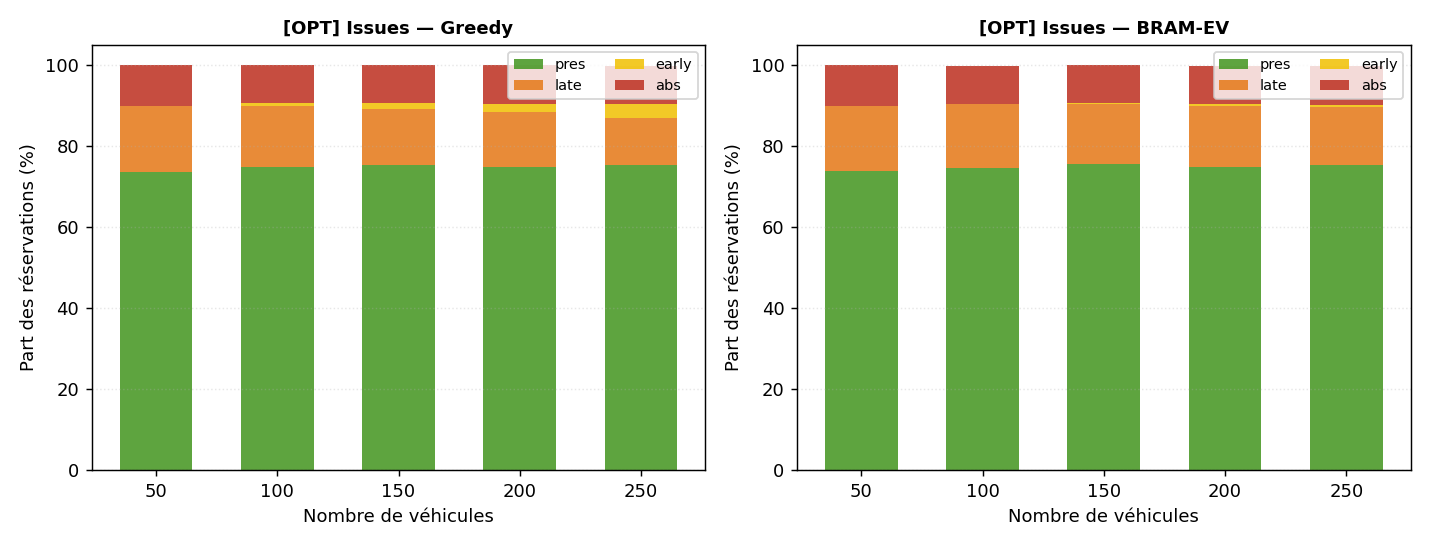

outcomes_pessimistic.png


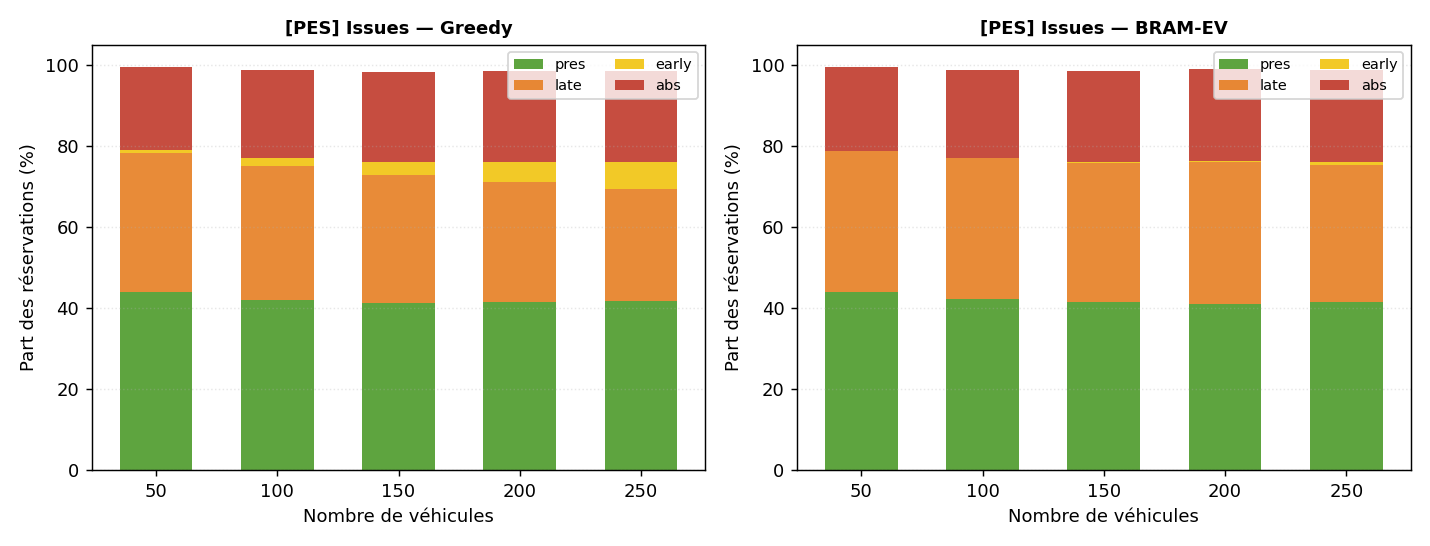

overview_satisfaction.png


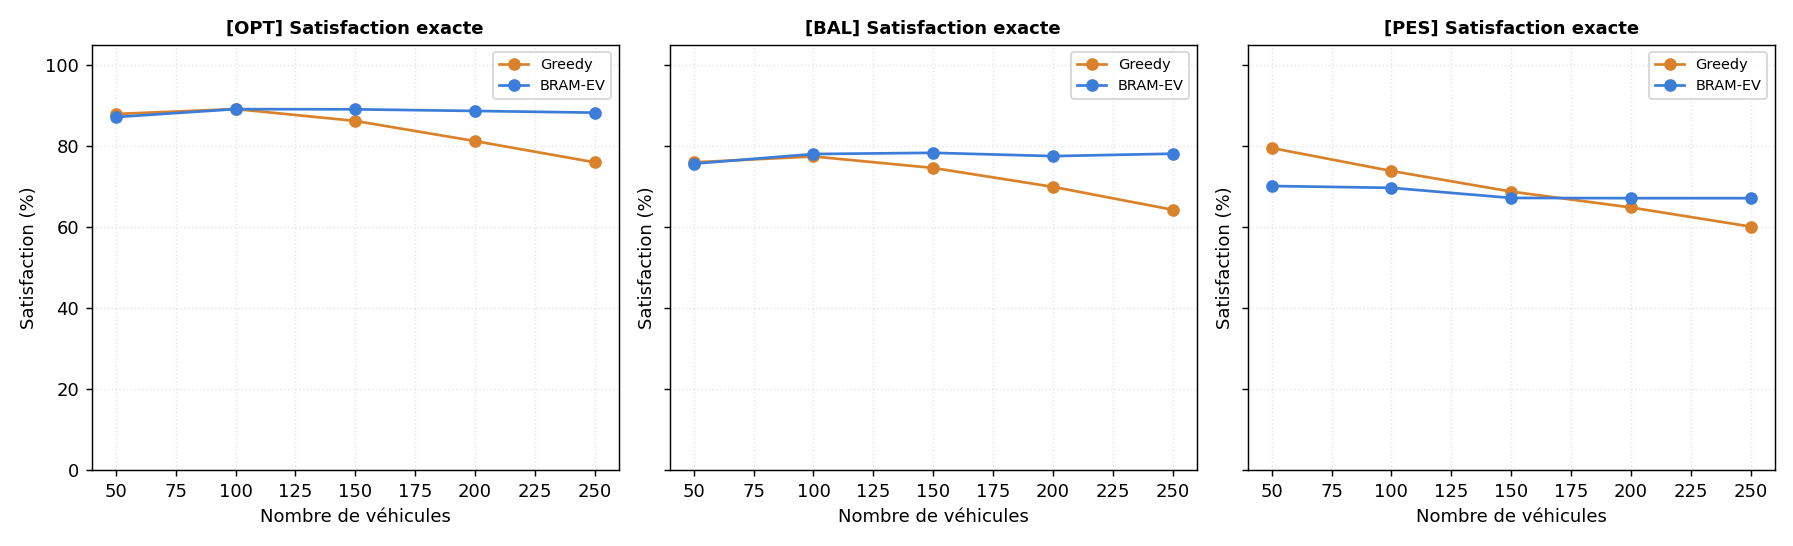

satisfaction_balance.png


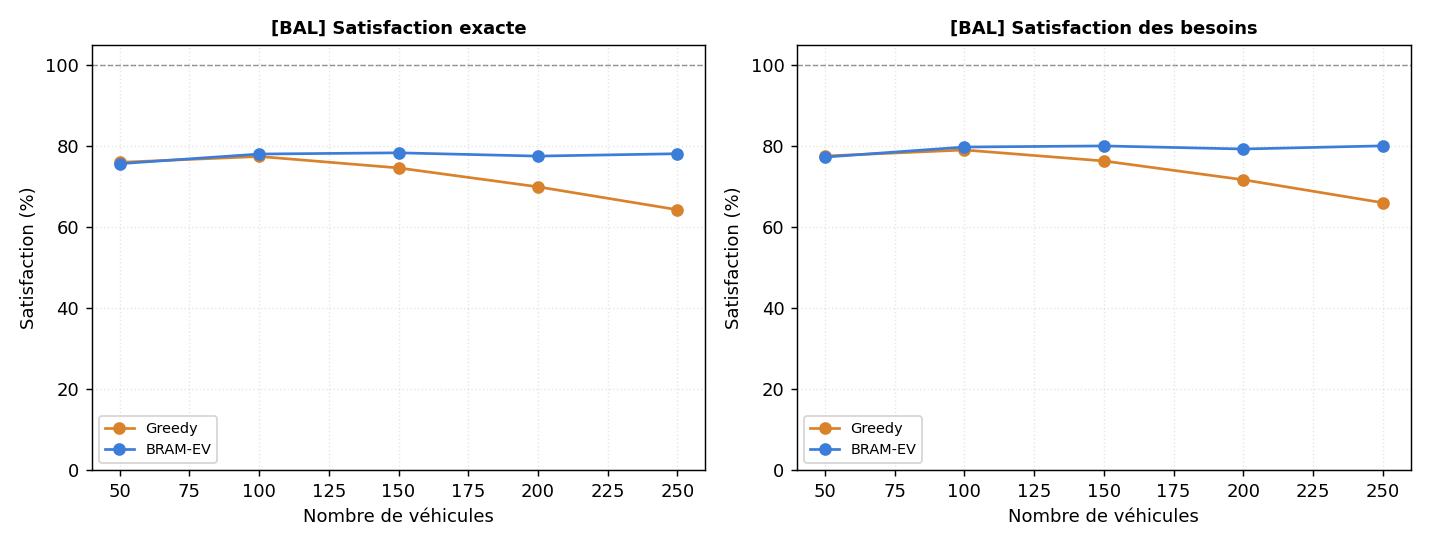

satisfaction_optimistic.png


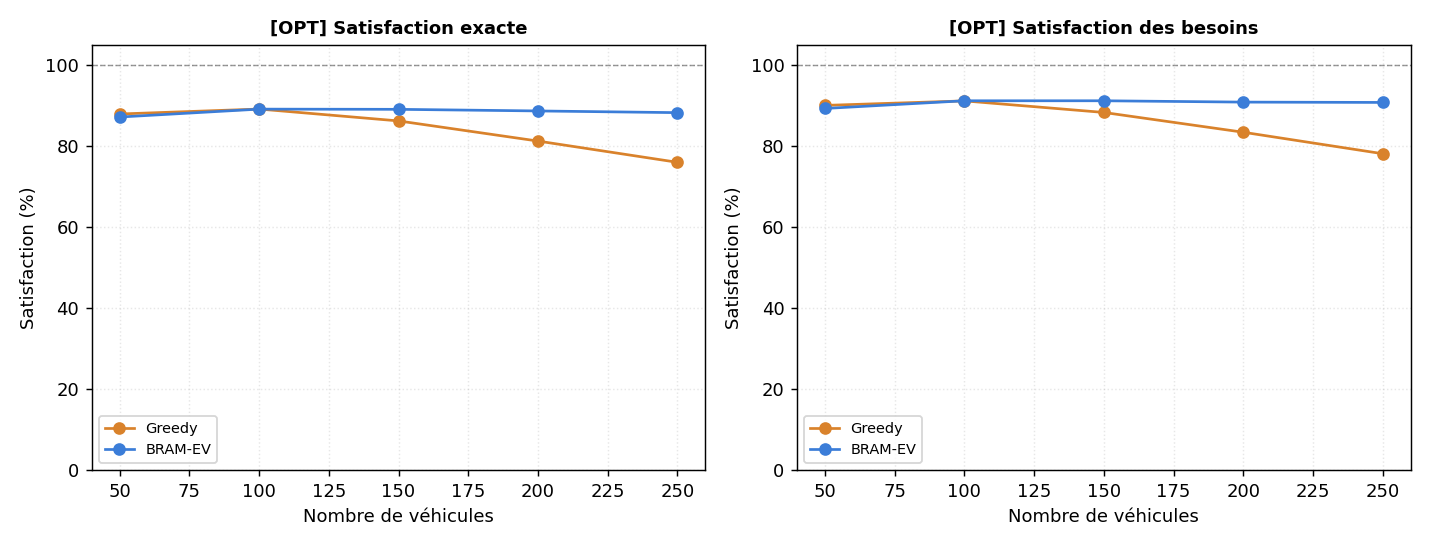

satisfaction_pessimistic.png


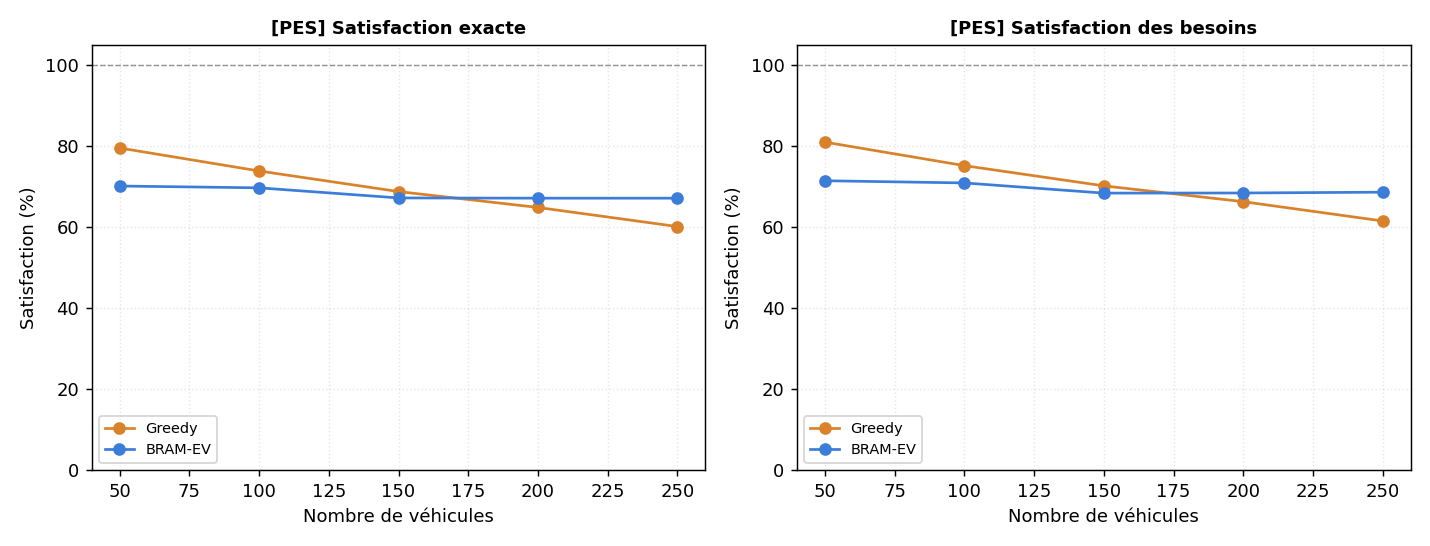

scalability.png


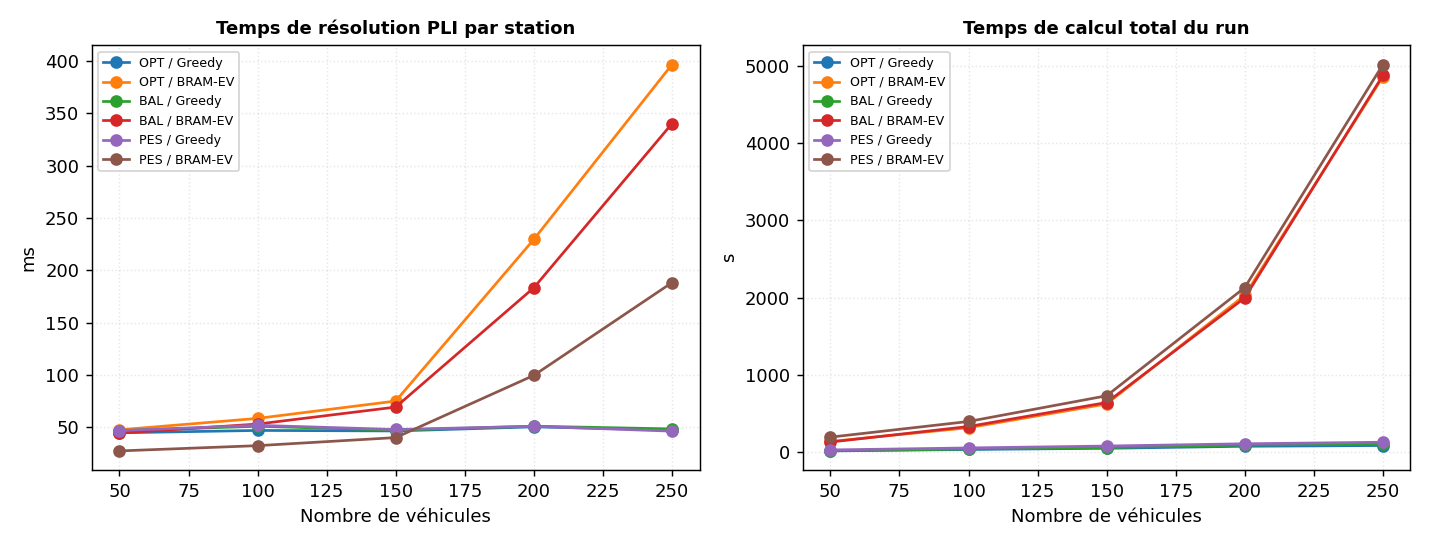

stations_balance.png


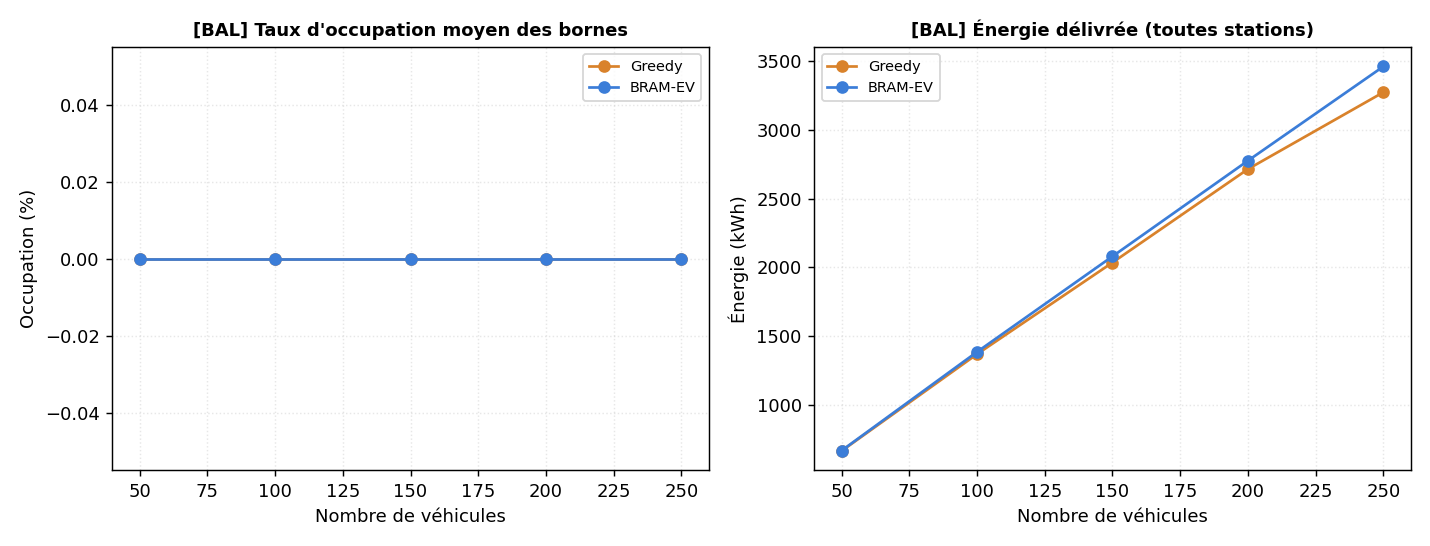

stations_optimistic.png


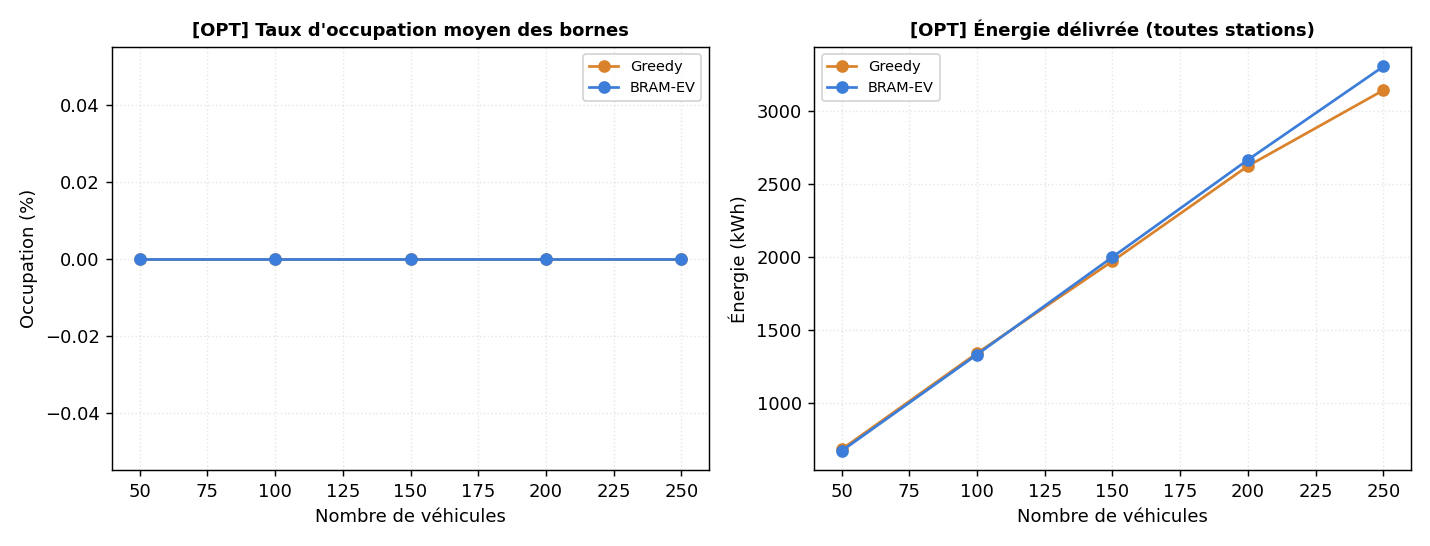

stations_pessimistic.png


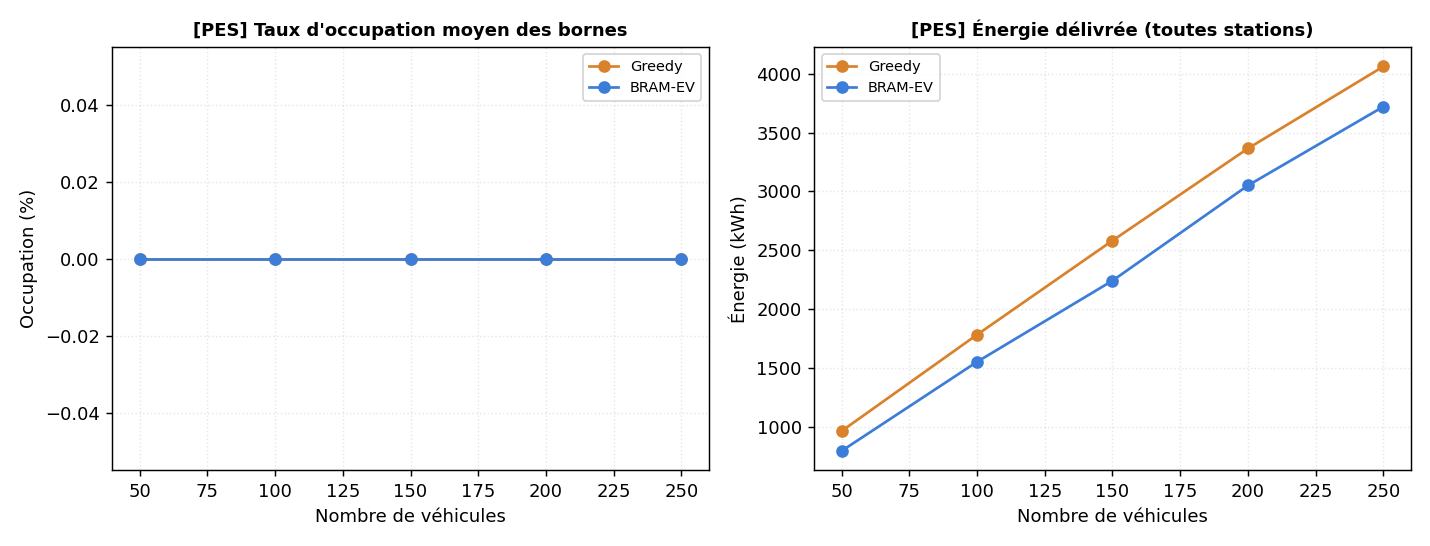

travel_waiting_balance.png


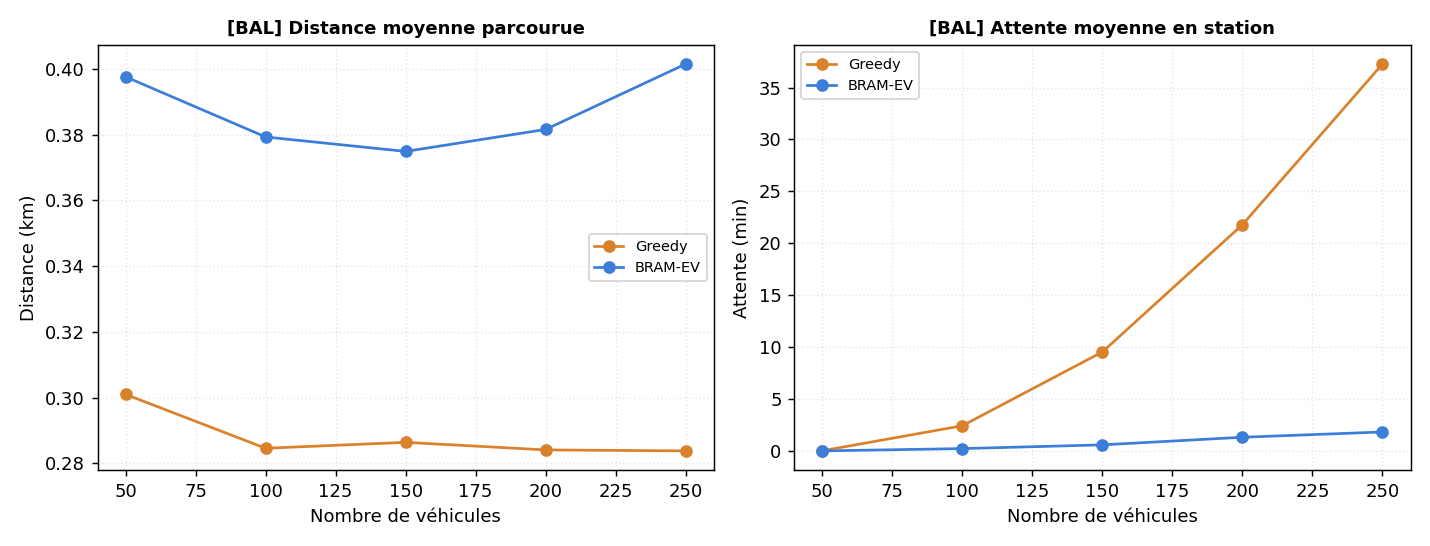

travel_waiting_optimistic.png


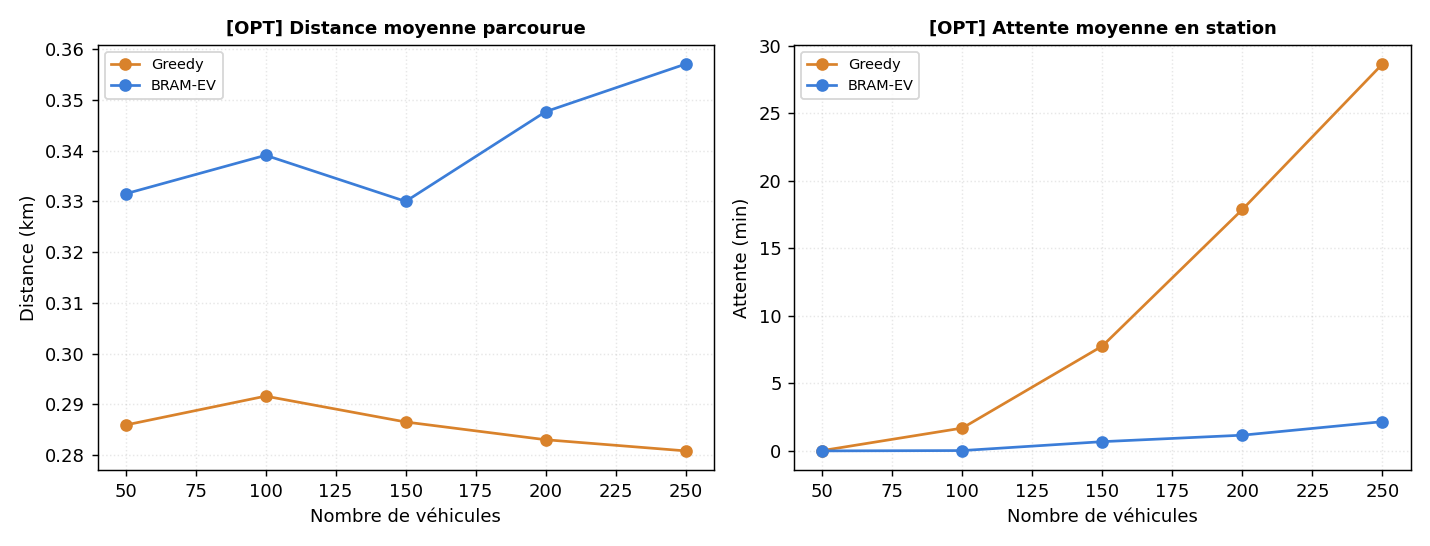

travel_waiting_pessimistic.png


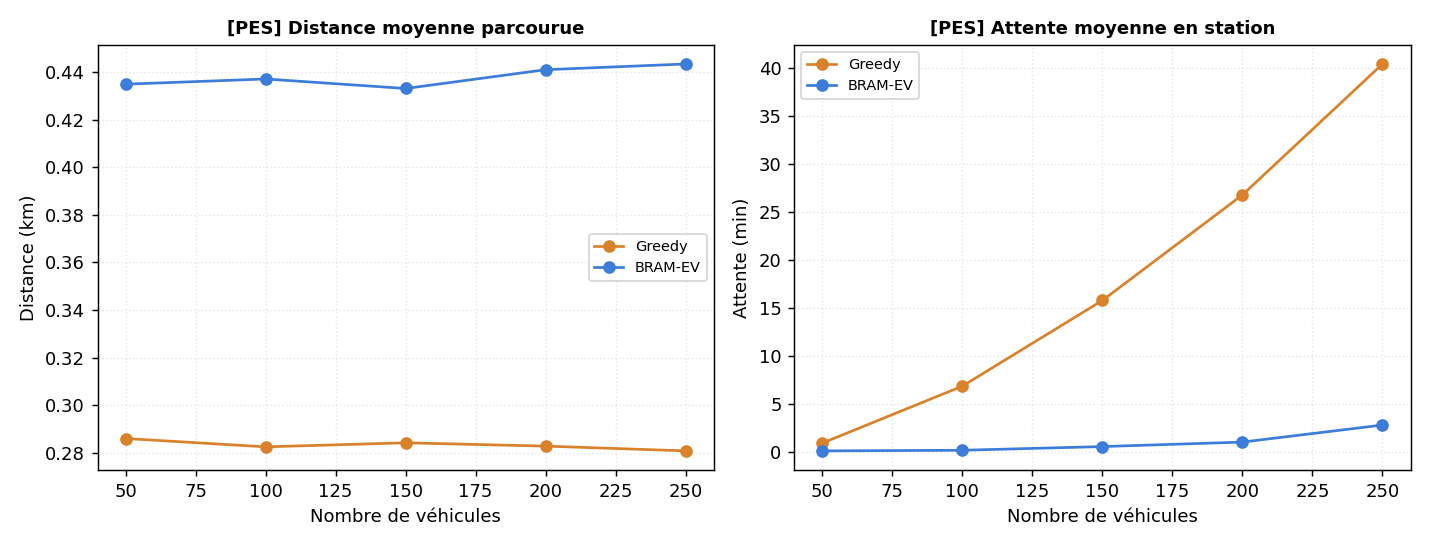

In [6]:
for path in sorted(store.figures_dir.glob('*.png')):
    print(path.name)
    display(Image(filename=str(path)))

## Tables détaillées

Une table par cas : `stations`, `behaviors`, `acceptances`, `alpha`, `latency`.

In [7]:
from src.pipeline.params import CaseParams

case = CaseParams(scenario=params.scenarios[-1],
                  nb_cars=params.fleet_sizes[-1],
                  method='bramev')

stations = pd.read_csv(store.table_path(case, 'stations'))
stations[['station_id', 'nb_charg_spot', 'alpha', 'occupancy_rate',
          'nb_reservations', 'nb_pres', 'nb_no_show', 'nb_late_canc',
          'nb_offer_issued', 'nb_offer_expired']].head(15)

,station_id,nb_charg_spot,alpha,occupancy_rate,nb_reservations,nb_pres,nb_no_show,nb_late_canc,nb_offer_issued,nb_offer_expired
0,0,5,0.2940,0.0,171,84,43,40,296,125
1,1,5,0.4676,0.0,24,12,4,8,320,296
2,2,5,0.4677,0.0,17,4,6,7,146,129
3,3,5,0.5262,0.0,161,66,38,51,329,168
4,4,5,0.2328,0.0,155,74,32,45,305,150
5,5,4,0.2665,0.0,33,14,9,10,146,113
6,6,6,0.5118,0.0,13,6,2,5,165,152
7,7,6,0.4025,0.0,26,9,8,8,143,117
8,8,5,0.5503,0.0,22,7,5,10,213,191
9,9,4,0.5552,0.0,59,17,11,29,309,250


In [8]:
latency = pd.read_csv(store.table_path(case, 'latency'))
latency[['demand_id', 'nb_stations', 'nb_offers', 'confirmed',
         'first_offer_ms', 'last_offer_ms', 'selection_ms',
         'confirmation_ms', 'total_ms']].describe()

,nb_stations,nb_offers,first_offer_ms,last_offer_ms,selection_ms,confirmation_ms,total_ms
count,6826.000000,6826.000000,2.681000e+03,2.681000e+03,2681.000000,2681.000000,2.681000e+03
mean,5.667008,1.393349,9.635858e+03,4.551627e+04,5025.190639,0.012605,5.054147e+04
std,2.803925,2.341123,9.322387e+04,4.086149e+05,54012.901810,0.008749,4.516476e+05
min,0.000000,0.000000,2.031792e+00,2.031792e+00,0.006000,0.003041,5.903583e+00
25%,3.000000,0.000000,7.753475e+01,2.793413e+02,11.214459,0.005625,4.295176e+02
50%,5.000000,0.000000,1.517221e+02,5.710768e+02,68.958292,0.007708,7.448909e+02
75%,7.000000,2.000000,3.134533e+02,9.703928e+02,208.933792,0.018208,1.162890e+03
max,16.000000,16.000000,1.515741e+06,4.159048e+06,768566.814041,0.046750,4.159048e+06


## Intention tirée vs issue observée

Écart entre les probabilités du scénario et ce qui se réalise effectivement.

In [9]:
behaviors = pd.read_csv(store.table_path(case, 'behaviors'))
behaviors.pivot_table(index='label', columns='kind', values='count', fill_value=0)

kind,intent,observed,reclassified
label,,,
abs,638.0,606.0,0.0
breakdown,0.0,32.0,0.0
early,393.0,26.0,0.0
early->late,0.0,0.0,367.0
late,533.0,900.0,0.0
pres,1117.0,1116.0,0.0
unresolved,0.0,1.0,0.0


In [10]:
for result in store.iter_results():
    for warning in result['behaviors'].get('diagnostics', []):
        print(f"[{result['scenario']}/{result['config']['nb_cars']}/"
              f"{result['mode']}] {warning}\n")

[balance/100/bramev] Aucune annulation anticipée réalisée alors que le scénario en prévoit : toutes sont reclassées en tardives. Une annulation ne peut être anticipée que si la réservation est prise suffisamment à l'avance ; avec un délai requête → arrivée quasi nul, la distinction anticipé / tardif n'est pas mesurable et la probabilité 'early' du scénario se réalise en 'late'. Voir 'reclassified' et 'median_lead_slots'.

[balance/100/bramev] Délai moyen requête → arrivée prévue < 1 slot : les stations proposent des créneaux immédiats (rayon de recherche petit devant la vitesse par slot). Aucune réservation n'est prise à l'avance.

[balance/100/greedy] Délai moyen requête → arrivée prévue < 1 slot : les stations proposent des créneaux immédiats (rayon de recherche petit devant la vitesse par slot). Aucune réservation n'est prise à l'avance.

[balance/150/bramev] Délai moyen requête → arrivée prévue < 1 slot : les stations proposent des créneaux immédiats (rayon de recherche petit devan